In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("./data/cltv_ecommerce.csv")
df

,customer_id,country,device_type,acquisition_channel,recency_days,frequency_orders,avg_order_value,discount_usage_pct,customer_service_tickets,days_as_member,is_vip_member,cltv_revenue
0,CUST_00001,UK,iOS,Google_Organic,124,2,72.71,0.4367,2,852,0,200.70
1,CUST_00002,Brazil,iOS,TikTok_Ads,159,1,111.26,0.3516,0,465,0,193.68
2,CUST_00003,Canada,Android,Affiliate_Partner,316,6,133.74,0.4963,1,825,1,2680.81
3,CUST_00004,Germany,Desktop_Mac,Facebook_Ads,1,6,29.95,0.4244,0,409,0,323.65
4,CUST_00005,USA,Android,Facebook_Ads,174,5,86.52,0.5748,1,330,0,510.12
...,...,...,...,...,...,...,...,...,...,...,...,...
24995,CUST_24996,USA,Android,Email_Newsletter,67,3,89.33,0.3519,1,1045,0,465.13
24996,CUST_24997,Canada,iOS,Direct_TypeIn,191,3,88.72,0.3065,0,695,0,465.90
24997,CUST_24998,India,Android,Affiliate_Partner,360,8,61.72,0.4191,0,916,0,959.70
24998,CUST_24999,France,Android,Google_Organic,351,5,88.12,0.2076,2,807,1,1236.69


In [3]:
df.shape

(25000, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               25000 non-null  str    
 1   country                   25000 non-null  str    
 2   device_type               25000 non-null  str    
 3   acquisition_channel       25000 non-null  str    
 4   recency_days              25000 non-null  int64  
 5   frequency_orders          25000 non-null  int64  
 6   avg_order_value           25000 non-null  float64
 7   discount_usage_pct        25000 non-null  float64
 8   customer_service_tickets  25000 non-null  int64  
 9   days_as_member            25000 non-null  int64  
 10  is_vip_member             25000 non-null  int64  
 11  cltv_revenue              25000 non-null  float64
dtypes: float64(3), int64(5), str(4)
memory usage: 2.3 MB


In [5]:
df.describe()

,recency_days,frequency_orders,avg_order_value,discount_usage_pct,customer_service_tickets,days_as_member,is_vip_member,cltv_revenue
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000
mean,181.670680,5.687120,90.454390,0.300452,0.801720,559.054400,0.18592,1175.440661
std,104.621938,3.979138,43.775812,0.172923,0.896726,308.363727,0.38905,1492.668423
min,1.000000,1.000000,16.760000,0.000000,0.000000,30.000000,0.00000,28.190000
25%,91.000000,3.000000,58.250000,0.149600,0.000000,290.000000,0.00000,342.330000
50%,181.000000,5.000000,82.440000,0.299650,1.000000,557.000000,0.00000,606.095000
75%,271.000000,8.000000,113.290000,0.450125,1.000000,828.000000,0.00000,1327.717500
max,364.000000,35.000000,364.660000,0.600000,6.000000,1094.000000,1.00000,22756.330000


In [6]:
df.isna().sum()

customer_id                 0
country                     0
device_type                 0
acquisition_channel         0
recency_days                0
frequency_orders            0
avg_order_value             0
discount_usage_pct          0
customer_service_tickets    0
days_as_member              0
is_vip_member               0
cltv_revenue                0
dtype: int64

In [7]:
df.drop(columns = 'customer_id').duplicated().sum()

np.int64(0)

In [8]:
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_col = df.select_dtypes(include='str').columns.tolist()

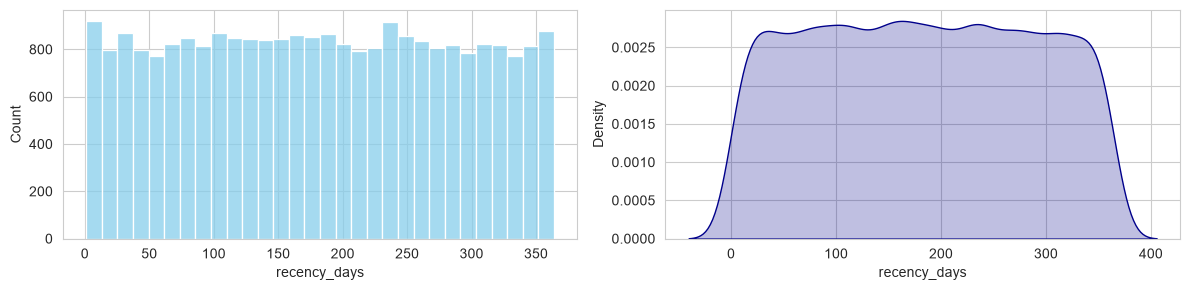

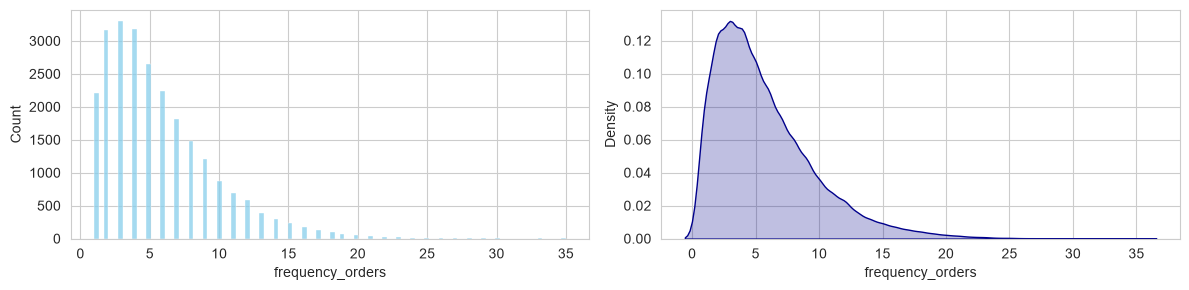

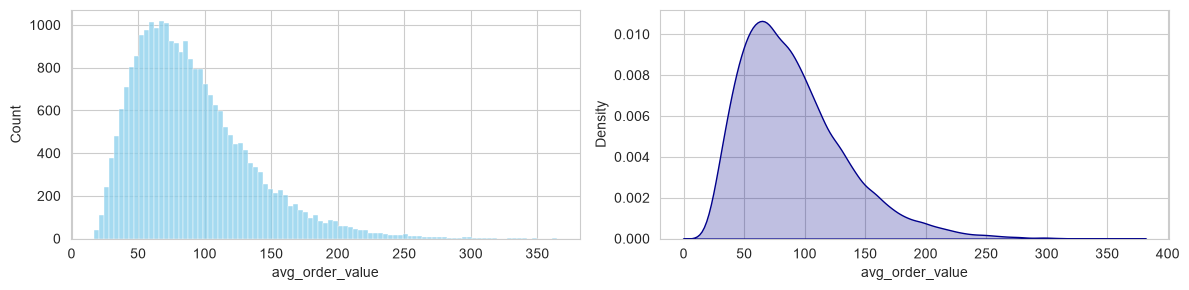

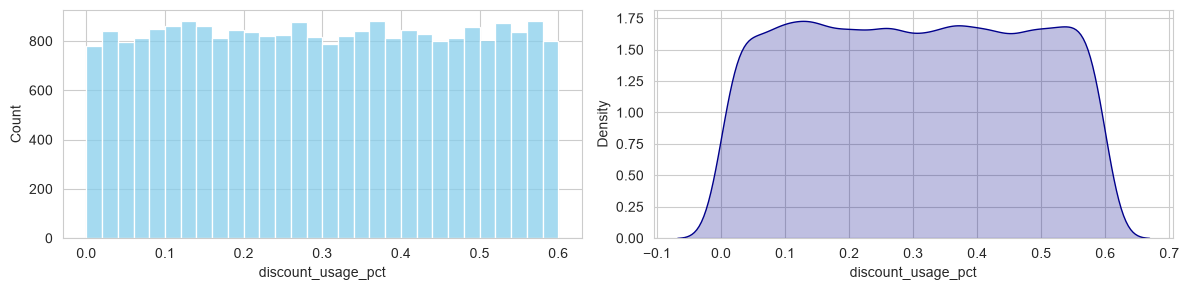

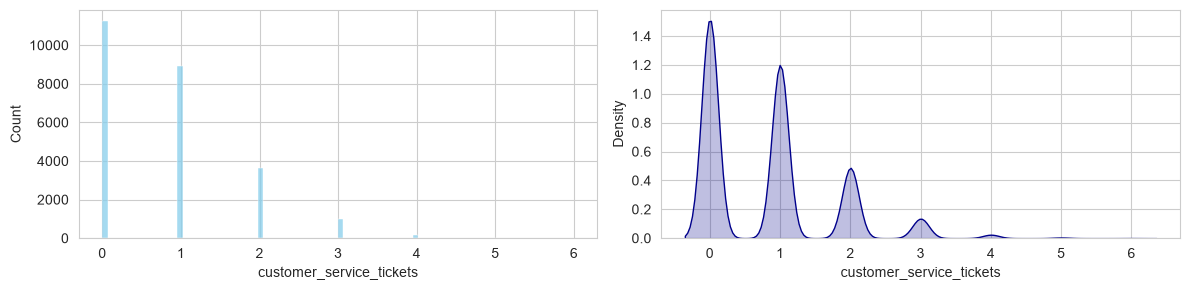

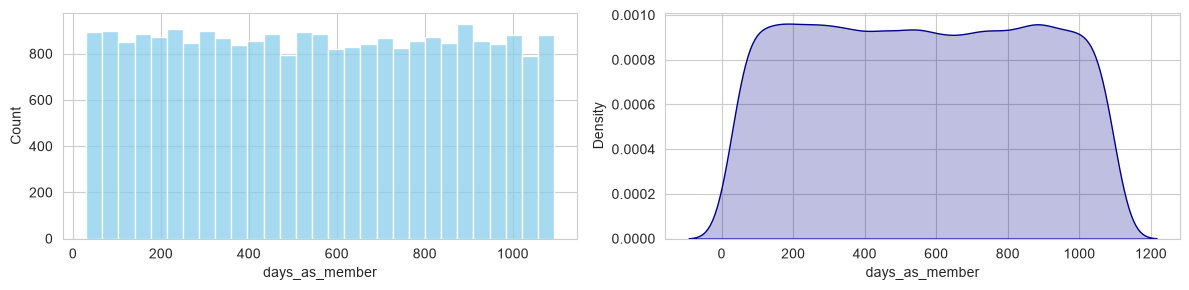

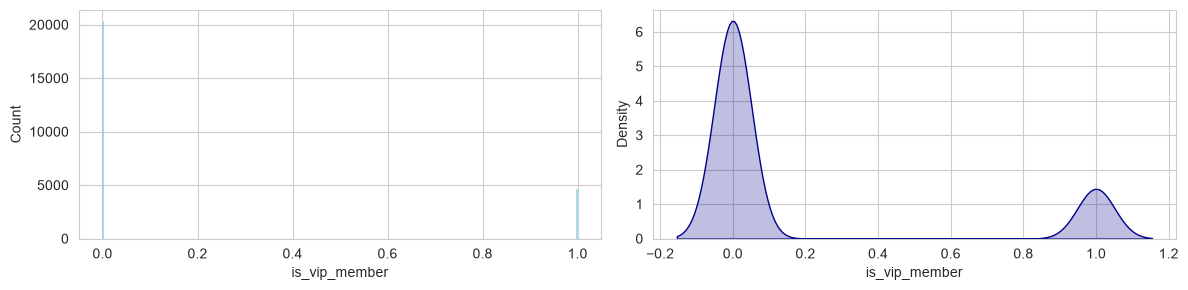

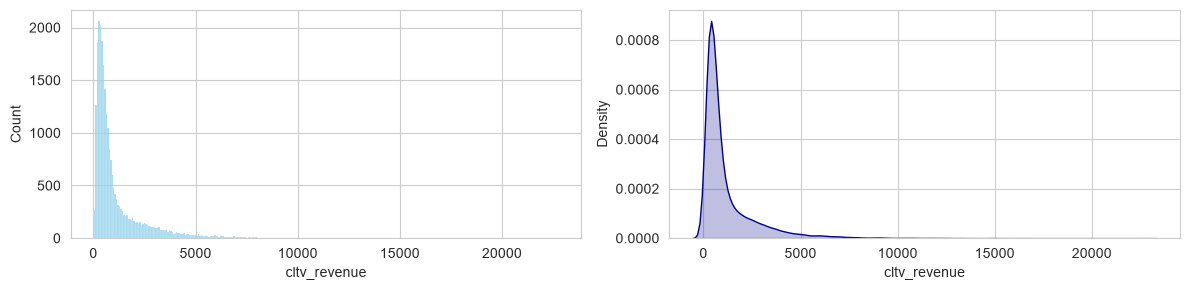

In [9]:
for col in num_cols:
    fig, axes = plt.subplots(1,2,figsize=(12,3))
    sns.histplot(df[col], ax = axes[0],color='skyblue')
    sns.kdeplot(df[col], ax = axes[1],fill = True, color= 'darkblue')
    plt.tight_layout()
    plt.show()

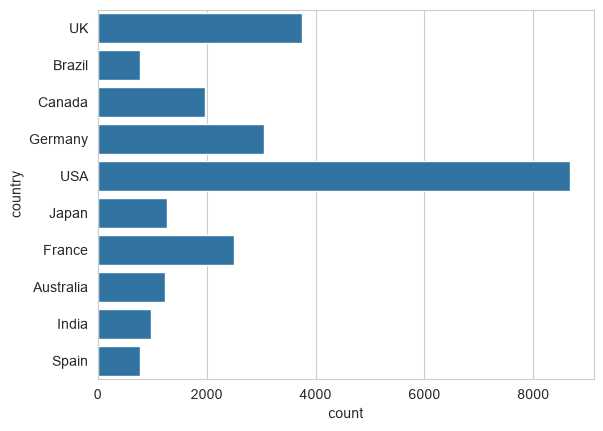

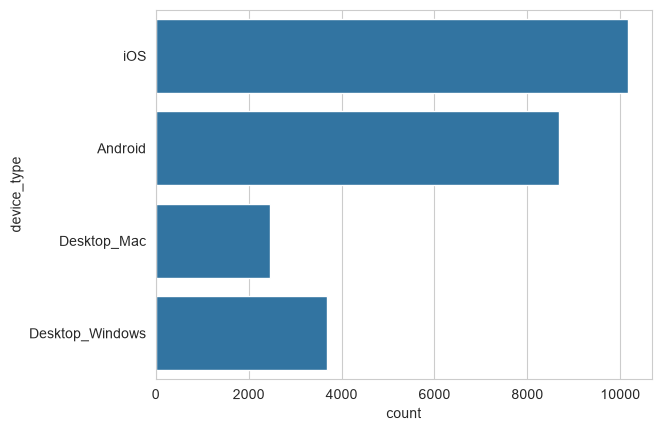

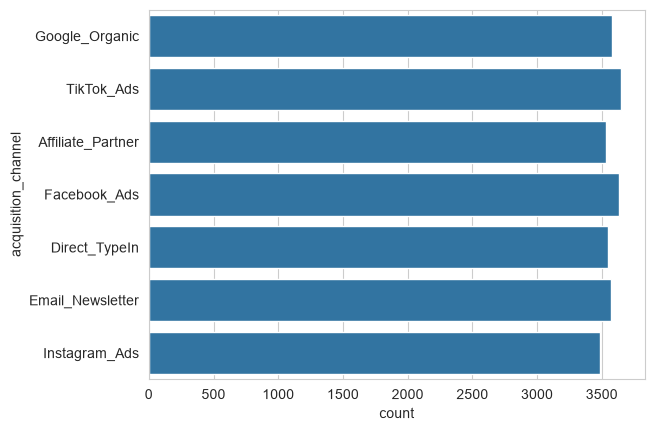

In [10]:
for col in cat_col:
    if col == 'customer_id':
        continue
    sns.countplot(df[col])
    plt.show()

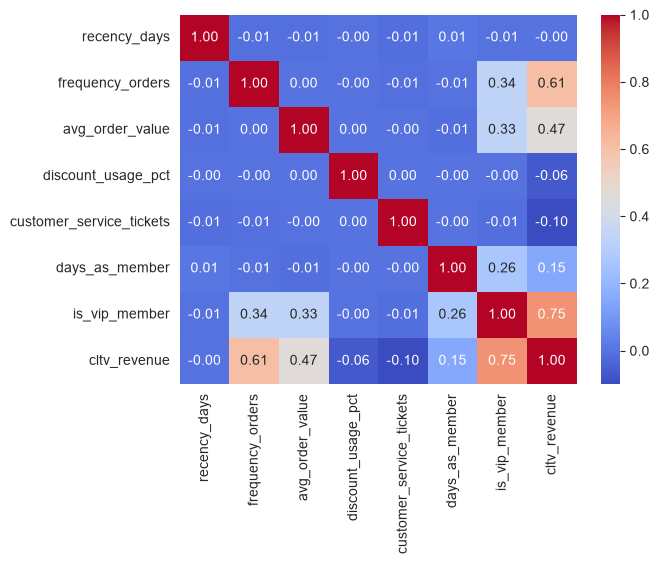

In [13]:
sns.heatmap(df[num_cols].corr(), annot = True, cmap = 'coolwarm', fmt='.2f')
plt.show()

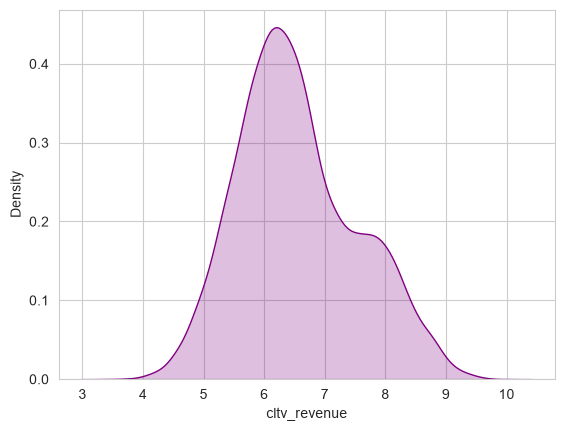

In [14]:
sns.kdeplot(np.log1p(df['cltv_revenue']), fill=True, color='purple')
plt.show()

In [15]:
X = df.drop(columns = ['customer_id', 'cltv_revenue'])
y = df['cltv_revenue']

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

cat_cols = ['country', 'device_type', 'acquisition_channel']
num_cols = [c for c in X.columns if c not in cat_cols and c != 'is_vip_member']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,np.log1p(df['cltv_revenue'])
,test_size = 0.2, random_state = 42)

In [33]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', LinearRegression())
])

pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['country','device_type','acquisition_channel',..., 'customer_service_tickets','days_as_member','is_vip_member']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically

In [26]:
pipe.score(X_test, y_test)

0.9062354905815614

In [27]:
pipe_r = Pipeline([
    ('preprocess', preprocessor),
    ('model', Ridge())
])

pipe_r.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['country','device_type','acquisition_channel',..., 'customer_service_tickets','days_as_member','is_vip_member']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically

In [28]:
pipe_r.score(X_test, y_test)

0.906236350299347

In [29]:
pipe_l = Pipeline([
    ('preprocess', preprocessor),
    ('model', Lasso())
])

pipe_l.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['country','device_type','acquisition_channel',..., 'customer_service_tickets','days_as_member','is_vip_member']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically

In [32]:
from sklearn.metrics import r2_score
r2_score(y_test, pipe_l.predict(X_test))

-1.0871484089625127e-05

In [34]:
pipe_s = Pipeline([
    ('preprocess', preprocessor),
    ('model', SGDRegressor())
])

pipe_s.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['country','device_type','acquisition_channel',..., 'customer_service_tickets','days_as_member','is_vip_member']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically

In [35]:
pipe_s.score(X_test, y_test)

0.9011478612799645

In [39]:
from sklearn.tree import DecisionTreeRegressor

pipe_d = Pipeline([
    ('preprocess', preprocessor),
    ('model', DecisionTreeRegressor(max_depth=10, random_state=42))
])

pipe_d.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['country','device_type','acquisition_channel',..., 'customer_service_tickets','days_as_member','is_vip_member']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically

In [40]:
pipe_d.score(X_test, y_test)

0.9444163379008567

In [41]:
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

pipe_rf = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1))
])

pipe_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['country','device_type','acquisition_channel',..., 'customer_service_tickets','days_as_member','is_vip_member']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically

In [42]:
pipe_rf.score(X_test, y_test)

0.966294129209048

In [43]:
pipe_h = Pipeline([
    ('preprocess', preprocessor),
    ('model', HistGradientBoostingRegressor(random_state=42))
])

pipe_h.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['country','device_type','acquisition_channel',..., 'customer_service_tickets','days_as_member','is_vip_member']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically

In [44]:
pipe_h.score(X_test, y_test)

0.9733934786797528

In [45]:
from xgboost import XGBRegressor

pipe_x = Pipeline([
    ('preprocess', preprocessor),
    ('model', XGBRegressor(device='cuda'))
])

pipe_x.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['country','device_type','acquisition_channel',..., 'customer_service_tickets','days_as_member','is_vip_member']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically

In [46]:
pipe_x.score(X_test, y_test)

0.9702421085345352

# Hyper Parameter Tuning

## XGBoost

In [ ]:
from sklearn.model_selection import cross_val_score
from optuna import create_study

def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 200,600)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.10, log=True)
    max_depth = trial.suggest_int("max_depth", 4,10)
    subsample = trial.suggest_float("subsample", 0.6,1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.6,1.0)
    reg_alpha = trial.suggest_float("reg_alpha", 1e-8, 1.0, log = True)
    reg_lambda = trial.suggest_float("reg_lambda", 1.0,6.0)

    pipe_x_hpt = Pipeline([
        ('preprocess', preprocessor),
        ('model', XGBRegressor(device='cuda', 
            n_estimators = n_estimators, 
            learning_rate = learning_rate, 
            max_depth = max_depth, 
            subsample = subsample,
            colsample_bytree = colsample_bytree,
            reg_alpha = reg_alpha,
            reg_lambda = reg_lambda))
    ])

    res = cross_val_score(
        estimator=pipe_x_hpt,
        X = X_train, 
        y = y_train,
        cv = 5,
        scoring = 'r2'
    ).mean()

    return res

study = create_study(direction='maximize')

[I 2026-08-23 22:12:39,326] A new study created in memory with name: no-name-4f50d670-e440-4b96-ab6d-5cddc2b68839


In [56]:
study.optimize(objective, n_trials=10)

[I 2026-08-23 22:12:50,911] Trial 0 finished with value: 0.9466313523281595 and parameters: {'n_estimators': 210, 'learning_rate': 0.010793387313486629, 'max_depth': 9, 'subsample': 0.6637545607486656, 'colsample_bytree': 0.9052819470591208, 'reg_alpha': 0.08823526422583167, 'reg_lambda': 3.156964763826445}. Best is trial 0 with value: 0.9466313523281595.
[I 2026-08-23 22:13:05,574] Trial 1 finished with value: 0.9726198102284613 and parameters: {'n_estimators': 516, 'learning_rate': 0.023638884365379465, 'max_depth': 8, 'subsample': 0.6075333191934802, 'colsample_bytree': 0.9905007468501196, 'reg_alpha': 9.377350486376613e-08, 'reg_lambda': 5.690462073114968}. Best is trial 1 with value: 0.9726198102284613.
[I 2026-08-23 22:13:31,653] Trial 2 finished with value: 0.970449309121098 and parameters: {'n_estimators': 435, 'learning_rate': 0.030496566656172876, 'max_depth': 10, 'subsample': 0.7597519281700911, 'colsample_bytree': 0.7748768451509108, 'reg_alpha': 9.318200772872434e-06, 'reg

In [57]:
study.best_value

0.9733716873596998

In [58]:
study.best_params

{'n_estimators': 568,
 'learning_rate': 0.062370290216909985,
 'max_depth': 5,
 'subsample': 0.8214817951104545,
 'colsample_bytree': 0.7376099126817501,
 'reg_alpha': 3.125009510336618e-08,
 'reg_lambda': 3.550680340383548}

## HistGradientBoosting

In [59]:
def objective(trial):
    max_iter = trial.suggest_int("max_iter", 200, 600)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 1.0, log=True)
    max_depth = trial.suggest_int("max_depth", 4,15)
    l2_regularization = trial.suggest_float("l2_regularization", 1e-8, 5.0, log=True)

    pipe_x_hpt = Pipeline([
        ('preprocess', preprocessor),
        ('model', HistGradientBoostingRegressor(
            max_iter=max_iter,
            learning_rate=learning_rate,
            max_depth=max_depth,
            l2_regularization=l2_regularization
        ))
    ])

    res = cross_val_score(
        estimator=pipe_x_hpt,
        X = X_train, 
        y = y_train,
        cv = 5,
        scoring = 'r2'
    ).mean()

    return res

study = create_study(direction='maximize')

[I 2026-08-23 22:18:46,919] A new study created in memory with name: no-name-87c1a66e-fdb6-4dc1-bf04-10d6db52eec1


In [60]:
study.optimize(objective, n_trials=10)

[I 2026-08-23 22:19:00,902] Trial 0 finished with value: 0.9731494493134834 and parameters: {'max_iter': 536, 'learning_rate': 0.03005152303439525, 'max_depth': 7, 'l2_regularization': 1.9719470048670067e-07}. Best is trial 0 with value: 0.9731494493134834.
[I 2026-08-23 22:19:05,208] Trial 1 finished with value: 0.9730719525060522 and parameters: {'max_iter': 407, 'learning_rate': 0.045733541162028754, 'max_depth': 12, 'l2_regularization': 2.641961304909626e-07}. Best is trial 0 with value: 0.9731494493134834.
[I 2026-08-23 22:19:13,792] Trial 2 finished with value: 0.9731380709596434 and parameters: {'max_iter': 466, 'learning_rate': 0.017337759556428474, 'max_depth': 14, 'l2_regularization': 3.057744115059741e-06}. Best is trial 0 with value: 0.9731494493134834.
[I 2026-08-23 22:19:14,834] Trial 3 finished with value: 0.9694287049041183 and parameters: {'max_iter': 435, 'learning_rate': 0.379749512056933, 'max_depth': 9, 'l2_regularization': 0.0001286799116655342}. Best is trial 0 w

In [61]:
study.best_value

0.9731494493134834

In [62]:
study.best_params

{'max_iter': 536,
 'learning_rate': 0.03005152303439525,
 'max_depth': 7,
 'l2_regularization': 1.9719470048670067e-07}